# Retail Data Exploration

## Load the data

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

In [3]:
df = pd.read_excel("../data/raw/online_retail/online_retail_II.xlsx")

## Dataset overview

In [5]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[us]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 32.1+ MB


In [7]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,525461.000000,525461,525461.000000,417534.000000
mean,10.337667,2010-06-28 11:37:36.845018,4.688834,15360.645478
min,-9600.000000,2009-12-01 07:45:00,-53594.360000,12346.000000
25%,1.000000,2010-03-21 12:20:00,1.250000,13983.000000
50%,3.000000,2010-07-06 09:51:00,2.100000,15311.000000
75%,10.000000,2010-10-15 12:45:00,4.210000,16799.000000
max,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000
std,107.424110,NaN,146.126914,1680.811316


The dataset contains transaction-level retail data from a UK online retailer and includes transactions recorded between 1 December 2009 and 9 December 2010. 

It contains both numerical and categorical variables describing invoices, products, customers and transactions.

## Data quality

### Data completeness

The dataset overview showed that the latest transaction was recorded on 9 December 2010. To determine whether the final month is complete, the number of transactions per month was examined.

In [67]:
df.groupby(df["InvoiceDate"].dt.to_period("M")).size()

InvoiceDate
2009-12    45228
2010-01    31555
2010-02    29388
2010-03    41511
2010-04    34057
2010-05    35323
2010-06    39983
2010-07    33383
2010-08    33306
2010-09    42091
2010-10    59098
2010-11    78015
2010-12    22523
Freq: M, dtype: int64

December 2010 contains far fewer transactions than the preceding months, confirming that the dataset includes only the first nine days of December. Due to this, December 2010 will be excluded from monthly comparison analysis.

### Missing values

In [12]:
# check number of missing values
df.isna().sum()

Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64

In [14]:
#  check percentage of missing values
(df.isna().sum() / len(df) * 100).round(2)

Invoice         0.00
StockCode       0.00
Description     0.56
Quantity        0.00
InvoiceDate     0.00
Price           0.00
Customer ID    20.54
Country         0.00
dtype: float64

Customer ID contains a substantial number of missing values, around 21%. Description has relatively few missing values only around 0.6%. Other columns appear complete.

### Duplicates

In [16]:
df.duplicated().sum()

np.int64(6865)

The dataset contains 6,865 duplicate rows. These will be removed during the data cleaning stage to avoid double-counting transactions.

### Negative quantities

In [17]:
(df["Quantity"] < 0).sum()

np.int64(12326)

In [18]:
df[df["Quantity"] < 0].head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
183,C489449,21871,SAVE THE PLANET MUG,-12,2009-12-01 10:33:00,1.25,16321.0,Australia
184,C489449,84946,ANTIQUE SILVER TEA GLASS ETCHED,-12,2009-12-01 10:33:00,1.25,16321.0,Australia
185,C489449,84970S,HANGING HEART ZINC T-LIGHT HOLDER,-24,2009-12-01 10:33:00,0.85,16321.0,Australia
186,C489449,22090,PAPER BUNTING RETRO SPOTS,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
196,C489459,90200A,PURPLE SWEETHEART BRACELET,-3,2009-12-01 10:44:00,4.25,17592.0,United Kingdom


There are 12,326 rows with negative quantities, which appear to represent cancelled orders or product returns, as the sampled records have invoice numbers beginning with "C".

### Negative prices

In [19]:
(df["Price"] < 0).sum()

np.int64(3)

In [20]:
df[df["Price"] < 0]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,-53594.36,NaN,United Kingdom
276274,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,-44031.79,NaN,United Kingdom
403472,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,-38925.87,NaN,United Kingdom


Only three records contain negative prices. All are labelled "Adjust bad debt", suggesting these are accounting adjustments rather than product sales. These records will be removed during data cleaning.

## Data cleaning

In [ ]:
df_clean = df.copy()

In [ ]:
df_clean = df_clean.drop_duplicates()

In [ ]:
# remove negative quantities - using only completed sales data, disregarding returns or cancellations for this analysis
df_clean = df_clean[df_clean["Quantity"] > 0]

In [ ]:
# remove negative prices - these were associated with debt adjustments and not relevant in this analysis
df_clean = df_clean[df_clean["Price"] > 0]

In [ ]:
# create a new column for the sales revenue
df_clean["Revenue"] = df_clean["Quantity"] * df_clean["Price"]

A "Revenue" column was calculated above by multiplying "Quantity" by "Price", allowing sales to be analysed across time, countries and products.

In [ ]:
# check results
df_clean.shape

(504731, 9)

In [36]:
df_clean.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


The cleaned data now has 504,731 records (reduced from 525,460) and 9 columns, including the new "Revenue" column.

### Further cleaning

In [49]:
# check % of missing Customer ID's and Descriptions
df_clean[["Customer ID", "Description"]].isna().mean() * 100

Customer ID    20.568382
Description     0.000000
dtype: float64

Despite a high percentage of transactions with missing Customer IDs (20.57%), they will be retained, because they can still contribute to product, country and revenue analysis. They will be excluded only from customer-level analysis. There are no transactions with missing descriptions remaining after cleaning. 

In [ ]:
#  check data types
df_clean.dtypes

Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
Price                 float64
Customer ID           float64
Country                   str
Revenue               float64
dtype: object

All of the data types are correct, no conversions needed.

### Investigate unusual quantities and prices.

In [ ]:
df_clean["Quantity"].describe()

count    504731.000000
mean         11.516923
std          87.337497
min           1.000000
25%           1.000000
50%           3.000000
75%          12.000000
max       19152.000000
Name: Quantity, dtype: float64

In [48]:
df_clean.nlargest(20,"Quantity")[["Invoice", "Customer ID", "StockCode", "Description", "Quantity", "Price", "Country"]]

,Invoice,Customer ID,StockCode,Description,Quantity,Price,Country
90857,497946,13902.0,37410,BLACK AND WHITE PAISLEY FLOWER MUG,19152,0.10,Denmark
127166,501534,13902.0,21099,SET/6 STRAWBERRY PAPER CUPS,12960,0.10,Denmark
127168,501534,13902.0,21091,SET/6 WOODLAND PAPER PLATES,12960,0.10,Denmark
127169,501534,13902.0,21085,SET/6 WOODLAND PAPER CUPS,12744,0.10,Denmark
127167,501534,13902.0,21092,SET/6 STRAWBERRY PAPER PLATES,12480,0.10,Denmark
135027,502269,17940.0,21984,PACK OF 12 PINK PAISLEY TISSUES,10000,0.25,United Kingdom
135028,502269,17940.0,21982,PACK OF 12 SUKI TISSUES,10000,0.25,United Kingdom
135029,502269,17940.0,21980,PACK OF 12 RED SPOTTY TISSUES,10000,0.25,United Kingdom
135030,502269,17940.0,21981,PACK OF 12 WOODLAND TISSUES,10000,0.25,United Kingdom
93677,498152,13902.0,85220,SMALL FAIRY CAKE FRIDGE MAGNETS,9456,0.30,Denmark


Very large order quantities appear to represent genuine bulk purchases of low cost products, rather than obvious data errors, so these will be retained.

In [46]:
df_clean["Price"].describe()

count    504731.000000
mean          4.274692
std          64.093333
min           0.001000
25%           1.250000
50%           2.100000
75%           4.210000
max       25111.090000
Name: Price, dtype: float64

In [70]:
df_clean.nlargest(20,"Price")[["Invoice", "StockCode", "Description", "Quantity", "Price", "Country"]]

,Invoice,StockCode,Description,Quantity,Price,Country
241827,512771,M,Manual,1,25111.09,United Kingdom
517955,537632,AMAZONFEE,AMAZON FEE,1,13541.33,United Kingdom
135013,502263,M,Manual,1,10953.50,United Kingdom
135015,502265,M,Manual,1,10953.50,United Kingdom
342147,522796,M,Manual,1,10468.80,United Kingdom
358639,524159,M,Manual,1,10468.80,United Kingdom
372834,525399,M,Manual,1,10468.80,United Kingdom
74356,496115,M,Manual,1,8985.60,United Kingdom
374227,525473,M,Manual,1,7044.79,United Kingdom
129903,501766,M,Manual,1,6958.17,Norway


A number of administrative records (e.g. Manual, Adjustment and Amazon Fee entries) with unusually high prices were identified. These will be retained for this version of the project because they represent valid records rather than errors.

## Exploratory visual analysis

### Monthly revenue chart

As discussed in the data quality assessment, December 2010 contains only nine days of data and has been excluded from this analysis.

In [79]:
# create a Month column
df_clean["Month"] = df_clean["InvoiceDate"].dt.to_period("M")

In [80]:
# exclude Dec 2010
df_trend = df_clean[df_clean["Month"] != "2010-12"]

In [81]:
monthly_revenue = (df_trend.groupby("Month")["Revenue"].sum())

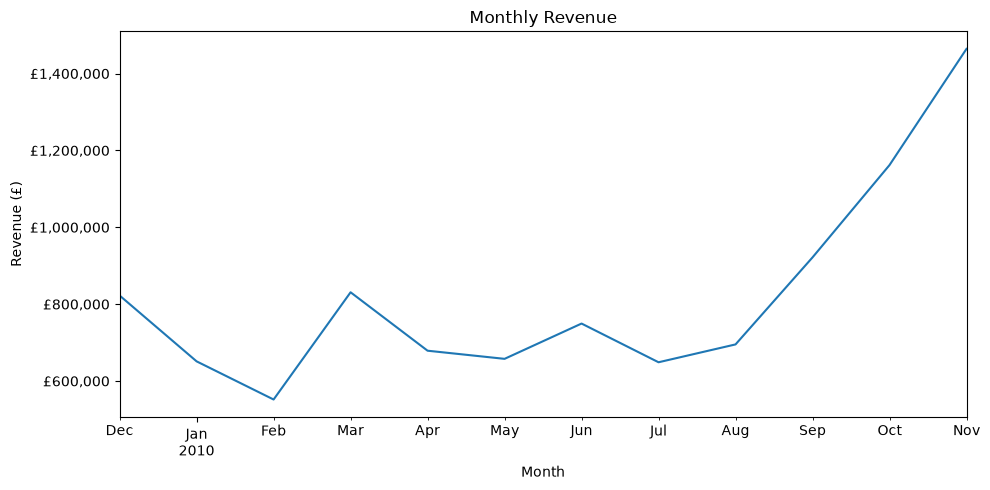

In [82]:
# plt.figure(figsize=(10, 5))
# monthly_revenue.plot()

# plt.title("Monthly Revenue")
# plt.xlabel("Month")
# plt.ylabel("Revenue (£)")

# plt.tight_layout()
# plt.show()

plt.figure(figsize=(10, 5))
monthly_revenue.plot()

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"£{x:,.0f}")
)

plt.tight_layout()
plt.show()

Revenue showed noticeable seasonal variation and a peak towards the end of the year. Revenue has decreased sharply after Dec 2009, with the lowest dip in Feb 2010. A slight peak in March was followed by a relatively stable spring/summer. Revenue increased sharply from September onwards, suggesting high sales in the run up to the holiday season. December 2010 was excluded due to incomplete records.

### Top countries by Revenue

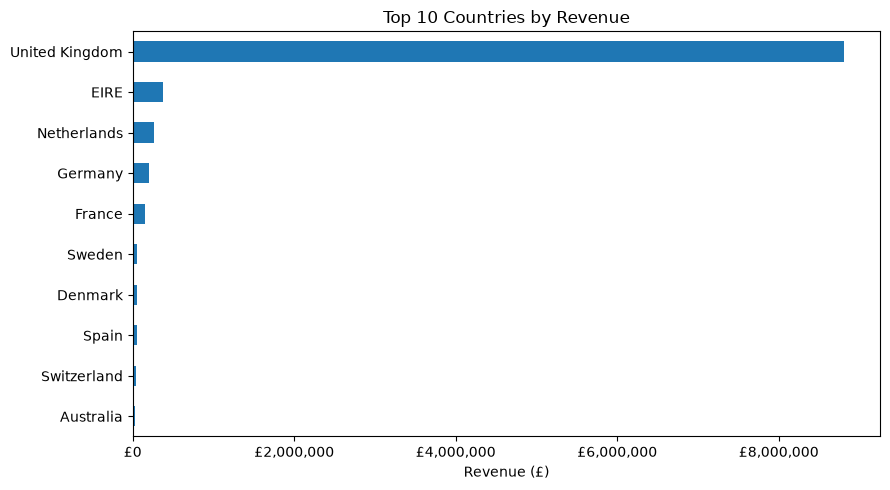

In [91]:
top_countries.plot(
    kind="barh",
    figsize=(9, 5)
)

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("")

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"£{x:,.0f}")
)

plt.tight_layout()
plt.show()

The chart revealed that the UK accounts for the majority of the revenue, and it is difficult to assess the differences between the other countries. A follow-up chart was created excluding the UK for a clearer comparison of the international revenue.

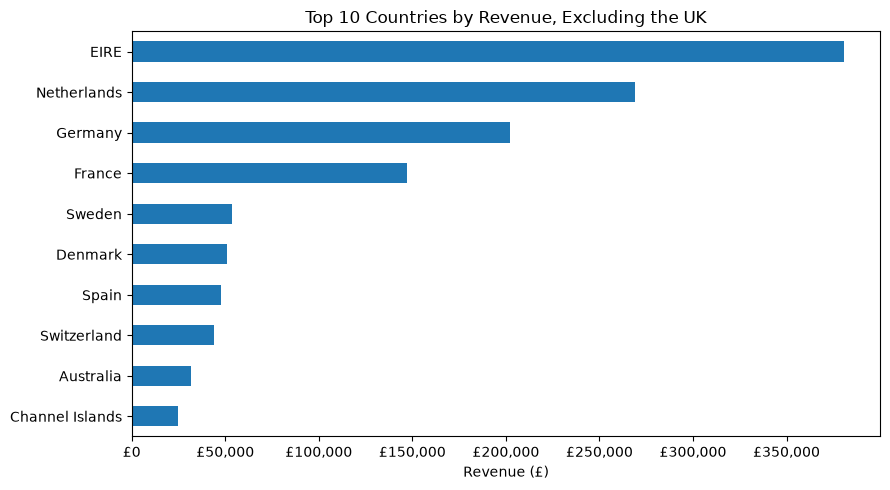

In [ ]:
top_countries_excluding_uk.plot(
    kind="barh",
    figsize=(9, 5)
)

plt.title("Top 10 Countries by Revenue, Excluding the UK")
plt.xlabel("Revenue (£)")
plt.ylabel("")

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"£{x:,.0f}")
)

plt.tight_layout()
plt.show()

EIRE is clearly the largest non-UK market (around £380,000).

The Netherlands is the second-largest (around £270,000).

Germany is third (around £200,000).

There is a noticeable drop from Germany to France.

After France, revenues fall sharply, with the remaining countries contributing relatively similar and much smaller amounts around £50,000 or less.

### Top products by revenue

In [94]:
top_products = (
    df_clean.groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
)

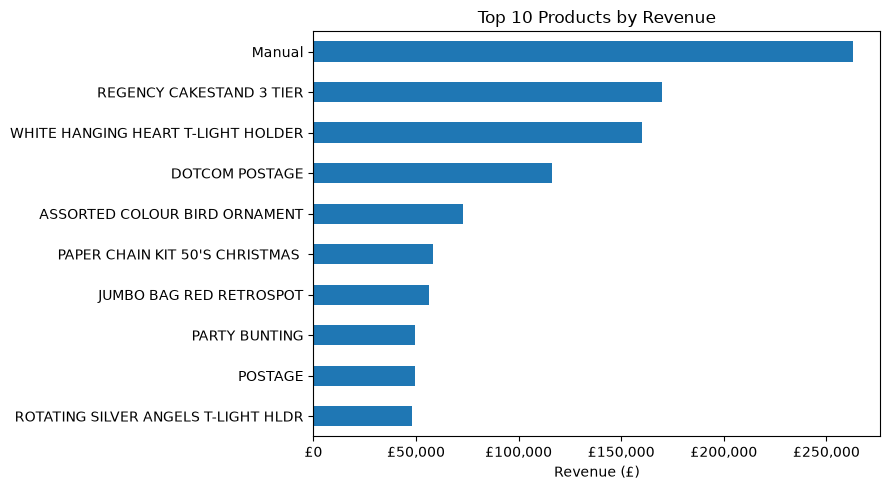

In [95]:
top_products.plot(
    kind="barh",
    figsize=(9, 5)
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("")

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"£{x:,.0f}")
)

plt.tight_layout()
plt.show()

The initial chart showed that "Manual", "DOTCOM POSTAGE", and "POSTAGE" were among the top products. These are administrative entries rather than retail products, so they were excluded in the following chart.

In [101]:
excluded = [
    "Manual",
    "POSTAGE",
    "DOTCOM POSTAGE"
]

top_retail_products = (
    df_clean[~df_clean["Description"].isin(excluded)]
    .groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
)

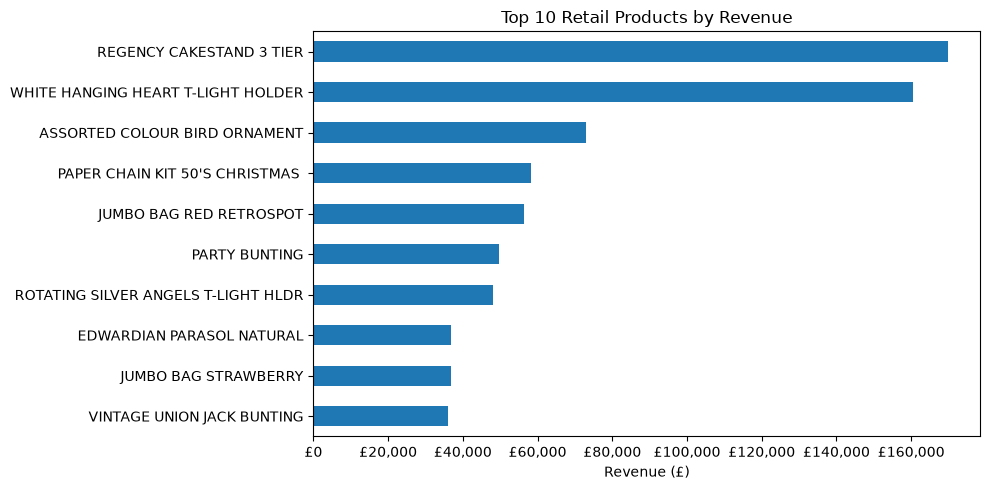

In [102]:
top_retail_products.plot(
    kind="barh",
    figsize=(10, 5)
)

plt.title("Top 10 Retail Products by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("")

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"£{x:,.0f}")
)

plt.tight_layout()
plt.show()

The two top-performing products generated substantially more revenue than the remaining items in the top ten. The 10th product generated less than a quarter of the revenue of the top-ranked product.

### Distribution of order values

In [103]:
order_values = (
    df_clean.groupby("Invoice")["Revenue"]
    .sum()
)

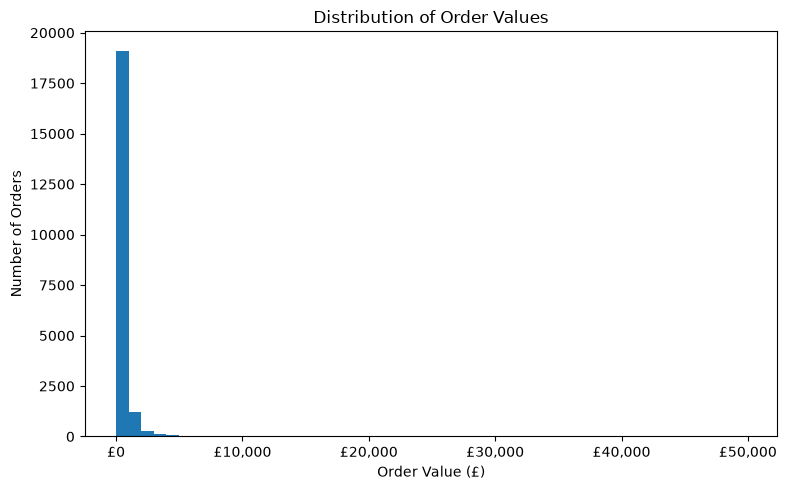

In [104]:
plt.figure(figsize=(8, 5))

plt.hist(
    order_values,
    bins=50
)

plt.title("Distribution of Order Values")
plt.xlabel("Order Value (£)")
plt.ylabel("Number of Orders")

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"£{x:,.0f}")
)

plt.tight_layout()
plt.show()

The chart is diificult to interpret, due to some very large orders causing a very right-skew distribution. 

In [ ]:
order_values.describe()

count    20952.000000
mean       490.269962
std       1116.019490
min          0.190000
25%        147.057500
50%        300.240000
75%        489.600000
max      49844.990000
Name: Revenue, dtype: float64

The median order value is around £300, the 75% is £490, while the maximum is nearly £50,000. To better visualise the distribution of typical order values, the histogram was limited to the 99th percentile in the following chart.

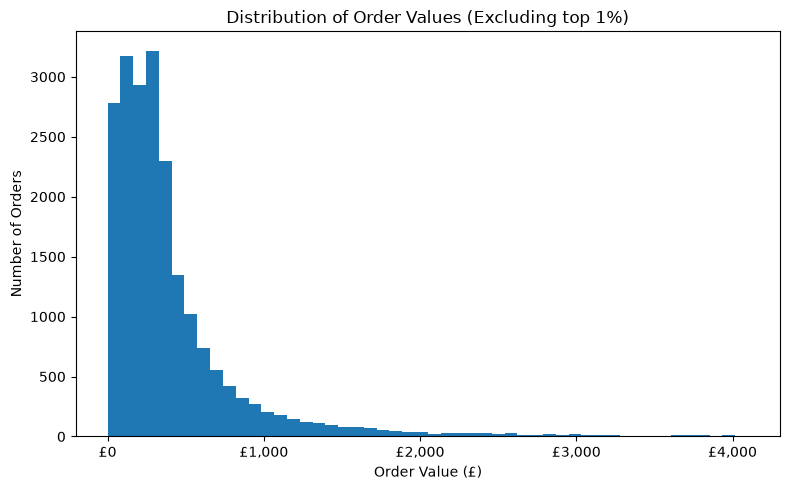

In [113]:
upper_limit = order_values.quantile(0.99)

plt.figure(figsize=(8, 5))

plt.hist(
    order_values[order_values <= upper_limit],
    bins=50
)

plt.title("Distribution of Order Values (Excluding top 1%)")
plt.xlabel("Order Value (£)")
plt.ylabel("Number of Orders")

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"£{x:,.0f}")
)

plt.tight_layout()
plt.show()

Most orders were for relatively low values, with the number of orders falling steadily as order values increased. Very few orders were worth more than £1,000, with the most common order values between around £200-£400.

## Key findings

## Next steps planned

Cleaning script, SQL analysis, dashboard, automated pipeline

write readme